# Do Clef-Flash probabilities remain coherent across equivalent questions?

This experiment transforms TweetEval sentiment into several views of the same mutually exclusive and exhaustive latent variable:

- a three-way `choice` over negative, neutral, and positive;
- a three-level ordinal `score` using the same ordering;
- one `noul` question for each label.

If all outputs represented one coherent categorical distribution, their probability vectors would agree and the three binary yes-probabilities would sum to one. Clef-Flash scores each question separately, so this notebook measures rather than assumes those identities.

In [1]:
from dataclasses import asdict
from pathlib import Path
import os
import sys

import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))

from decision_models.benchmark import (
    SENTIMENT_LABELS,
    coherence_metrics,
    load_tweet_eval_records,
)
from decision_models.clef_flash import ClefFlashClient

## Build the transformed dataset

Start small because Clef-Flash is a 9B model. Increase `N_EXAMPLES` after checking memory and runtime. The source labels are retained for accuracy/calibration analysis, but they are not sent to the model.

In [2]:
N_EXAMPLES = int(os.environ.get('CLEF_N_EXAMPLES', '100'))
records = load_tweet_eval_records(split='test', limit=N_EXAMPLES)
records[0]

{'state': {'text': "@user @user what do these '1/2 naked pics' have to do with anything? They're not even like that."},
 'questions': {'sentiment_choice': {'type': 'choice',
   'instructions': 'What is the overall sentiment of this text?',
   'criteria': {'negative': 'The overall sentiment expressed by the text is negative.',
    'neutral': 'The text is neutral or does not express a clear sentiment.',
    'positive': 'The overall sentiment expressed by the text is positive.'}},
  'sentiment_score': {'type': 'score',
   'instructions': 'Rate the overall sentiment on the ordered scale from negative through neutral to positive.',
   'criteria': ['The overall sentiment expressed by the text is negative.',
    'The text is neutral or does not express a clear sentiment.',
    'The overall sentiment expressed by the text is positive.']},
  'is_negative': {'type': 'noul',
   'instructions': 'Is the overall sentiment of this text negative?',
   'criteria': {'true': 'The overall sentiment expres

## Load and run Clef-Flash

The official release is loaded lazily from `Cloudflare/clef-flash`. It was tested by its publisher with Torch 2.11 and Transformers 5.10.2 on an H200. Set the flag only on a suitable CUDA machine. Pin `REVISION` for a publication-quality run.

In [3]:
RUN_MODEL = os.environ.get('RUN_CLEF_FLASH', '0') == '1'
REVISION = None  # Replace with a Hugging Face commit hash for reproducibility.

if RUN_MODEL:
    clef = ClefFlashClient.from_pretrained(device='cuda', revision=REVISION)
    answers = [
        clef.decide(record['state'], record['questions'])
        for record in records
    ]
else:
    answers = []
    print('Set RUN_MODEL=True to download and evaluate Clef-Flash.')

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 17 files:   0%|          | 0/17 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/760 [00:00<?, ?it/s]

[transformers] `causal_conv1d_fn` is falling back to its reference PyTorch implementation because `causal_conv1d` is not installed. This is correct but much slower; install `causal_conv1d` for the optimized kernel.


[transformers] `chunk_gated_delta_rule` is falling back to its reference PyTorch implementation because `flash-linear-attention` is not installed. This is correct but much slower; install `flash-linear-attention` for the optimized kernel.


## Measure cross-formulation coherence

The four primary diagnostics are:

- mean L1 gap between `choice` and `score` distributions;
- mean L1 gap between `choice` and raw `noul` yes-probabilities;
- violation of the exhaustive simplex, `|sum(p_noul) - 1|`;
- choice/binary gap after normalizing binary values, separating relative disagreement from failure to sum to one.

In [4]:
if answers:
    rows = []
    for record, answer in zip(records, answers):
        row = asdict(coherence_metrics(answer))
        row['label'] = record['label_name']
        rows.append(row)
    metrics_df = pd.DataFrame(rows)
    display(metrics_df.describe(percentiles=[0.5, 0.9, 0.95, 0.99]).T)

,count,mean,std,min,50%,90%,95%,99%,max
choice_score_l1,100.0,0.037112,0.017124,0.005567,0.034600,0.057453,0.066903,0.082004,0.098933
choice_noul_l1,100.0,0.110641,0.049775,0.018433,0.120267,0.172050,0.194125,0.215919,0.224400
noul_simplex_error,100.0,0.304151,0.158764,0.000200,0.323700,0.486830,0.575345,0.647757,0.673200
choice_noul_normalized_l1,100.0,0.101629,0.048988,0.007860,0.105274,0.166552,0.170651,0.185281,0.193647


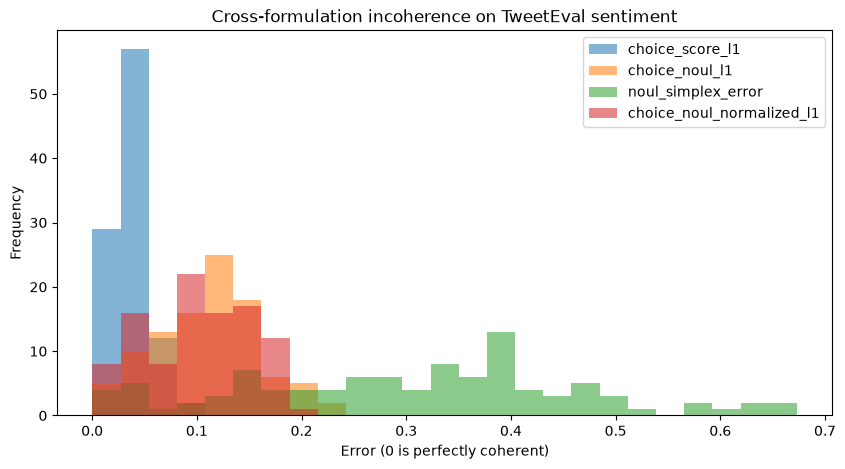

In [5]:
if answers:
    ax = metrics_df[[
        'choice_score_l1',
        'choice_noul_l1',
        'noul_simplex_error',
        'choice_noul_normalized_l1',
    ]].plot.hist(bins=25, alpha=0.55, figsize=(10, 5))
    ax.set_title('Cross-formulation incoherence on TweetEval sentiment')
    ax.set_xlabel('Error (0 is perfectly coherent)')

## Inspect the worst examples

Large errors may reflect genuine ambiguity, formulation sensitivity, or a mismatch between the intended logical equivalence and how the model interprets the prompt. Read examples before treating every discrepancy as a model defect.

In [6]:
if answers:
    worst = metrics_df.nlargest(10, 'choice_noul_l1').index
    for i in worst:
        print(f'\nExample {i}:', records[i]['state']['text'])
        print('Gold:', records[i]['label_name'])
        print('Metrics:', asdict(coherence_metrics(answers[i])))
        print('Answers:', answers[i])


Example 87: @user @user @user @user ☞ ISIS Films Men Laughing While Woman Is Raped in Background
Gold: negative
Metrics: {'choice_score_l1': 0.06949999999999999, 'choice_noul_l1': 0.22440000000000004, 'noul_simplex_error': 0.6732000000000002, 'choice_noul_normalized_l1': 0.18338957685871385}
Answers: {'sentiment_choice': {'type': 'choice', 'choice': 'neutral', 'confidence': 0.7633, 'probabilities': {'negative': 0.2187, 'neutral': 0.7633, 'positive': 0.018}}, 'sentiment_score': {'type': 'score', 'score': 0.7183, 'confidence': 0.659, 'legend': {'0': 'The overall sentiment expressed by the text is negative.', '1': 'The text is neutral or does not express a clear sentiment.', '2': 'The overall sentiment expressed by the text is positive.'}, 'probabilities': {'0': 0.3113, '1': 0.659, '2': 0.0296}}, 'is_negative': {'type': 'noul', 'noul': 0.8262}, 'is_neutral': {'type': 'noul', 'noul': 0.8273}, 'is_positive': {'type': 'noul', 'noul': 0.0197}}

Example 70: @user @user @user only wants adulat

## Structural baseline

`SharedUtilityHead` starts from one utility per proposition and derives every output from one softmax. It therefore has zero cross-formulation error by construction. Notice that exact binary coherence uses `sigmoid(u_i - logsumexp(u_not_i))`, not an independent `sigmoid(u_i)`.

In [7]:
import torch
from decision_models.coherent import SharedUtilityHead

u = torch.tensor([0.2, -0.4, 1.3])
p_choice = SharedUtilityHead.choice(u)
p_noul_yes = torch.stack([SharedUtilityHead.noul(u, i)[1] for i in range(3)])
p_score, expected_score = SharedUtilityHead.score(u, torch.tensor([-1., 0., 1.]))

print('choice:', p_choice)
print('noul yes marginals:', p_noul_yes, 'sum =', p_noul_yes.sum())
print('score distribution:', p_score, 'expectation =', expected_score)
torch.testing.assert_close(p_choice, p_noul_yes)
torch.testing.assert_close(p_choice, p_score)

choice: tensor([0.2196, 0.1205, 0.6598])
noul yes marginals: tensor([0.2196, 0.1205, 0.6598]) sum = tensor(1.)
score distribution: tensor([0.2196, 0.1205, 0.6598]) expectation = tensor(0.4402)


## Recommended extensions

1. Repeat each question with paraphrases and reordered options to separate logical inconsistency from wording/order sensitivity.
2. Report accuracy, Brier score, ECE, and coherence separately; a coherently wrong model is still wrong.
3. Bootstrap confidence intervals by example.
4. Fit calibration only on a validation split and evaluate once on the test split.
5. Compare Clef-Flash with `CoherentDecisionModel` using the same Qwen3.5-9B backbone and a trained shared-utility head.